In [1]:
#regular stuff
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import numpy.ma as ma
from astropy.table import Table
import astropy.io.fits as fits
from scipy.optimize import least_squares, minimize

import sys
sys.path.insert(1, '/Users/nityaravi/Documents/Github/RotationCurves/ellipticals/')

from IO_data import extract_Pipe3d_data, extract_data

In [3]:
#DIRECTORIES
PIPE3D_FOLDER = '/Users/nityaravi/Documents/Research/RotationCurves/data/manga/Pipe3D/'
DATA_FOLDER = '/Users/nityaravi/Documents/Research/RotationCurves/data/manga/'
VEL_FOLDER = DATA_FOLDER + 'DR17/'
master_table_fn = DATA_FOLDER + 'output_files/DR17/CURRENT_MASTER_TABLE/Elliptical_sphdisk_refitspirals_v4.fits'
dynpop_fn = DATA_FOLDER + '/dynpop/SDSSDR17_MaNGA_JAM.fits'


matplotlib.rcParams['figure.dpi'] = 100
matplotlib.rcParams['savefig.dpi'] = 300

In [4]:
master_table = Table.read(master_table_fn, format='fits')
master_table_dict = {}
for i in range(len(master_table)):
    master_table_dict[master_table['plateifu'][i]] = i
master_table[:5]


plate,ifudsgn,plateifu,mangaid,versdrp2,versdrp3,verscore,versutil,versprim,platetyp,srvymode,objra,objdec,ifuglon,ifuglat,ifura,ifudec,ebvgal,nexp,exptime,drp3qual,bluesn2,redsn2,harname,frlplug,cartid,designid,cenra,cendec,airmsmin,airmsmed,airmsmax,seemin,seemed,seemax,transmin,transmed,transmax,mjdmin,mjdmed,mjdmax,gfwhm,rfwhm,ifwhm,zfwhm,mngtarg1,mngtarg2,mngtarg3,catidnum,plttarg,manga_tileid,nsa_iauname,ifudesignsize,ifutargetsize,ifudesignwrongsize,z,zmin,zmax,szmin,szmax,ezmin,ezmax,probs,pweight,psweight,psrweight,sweight,srweight,eweight,esweight,esrweight,nsa_field,nsa_run,nsa_camcol,nsa_version,nsa_nsaid,nsa_nsaid_v1b,nsa_z,nsa_zdist,nsa_sersic_absmag,nsa_elpetro_absmag,nsa_elpetro_amivar,nsa_sersic_mass,nsa_elpetro_mass,nsa_elpetro_ba,nsa_elpetro_phi,nsa_extinction,nsa_elpetro_th50_r,nsa_petro_th50,nsa_petro_flux,nsa_petro_flux_ivar,nsa_elpetro_flux,nsa_elpetro_flux_ivar,nsa_sersic_ba,nsa_sersic_n,nsa_sersic_phi,nsa_sersic_th50,nsa_sersic_flux,nsa_sersic_flux_ivar,smoothness_score,nsa_elpetro_th90,v_sys,v_sys_err,ba,ba_err,x0,x0_err,y0,y0_err,phi,phi_err,v_max,v_max_err,r_turn,r_turn_err,chi2,alpha,alpha_err,Rmax,M,M_err,fit_flag,Sigma_disk,Sigma_disk_err,R_disk,R_disk_err,rho_bulge,rho_bulge_err,R_bulge,R_bulge_err,M90_disk,M90_disk_err,M_disk,M_disk_err,chi2_disk,logHI,logHIlim,WF50,WF50_err,DL_ttype,vis_tidal,b,b_err,M_R90,M_R90_err,fit_function,A_g,A_r,logH2,R90_kpc,v_3p5,v_3p5_err,NSA_plate,NSA_fiberID,NSA_MJD,logH2_CG,logH2_CG_err,logH2_M,Z,Z_err,M_Z,M_Z_err,grad_Z,grad_Z_err,Z_0,Z_0_err,SFR,sSFR,SFR_err,sSFR_err,Flux_OII_3726,Flux_OII_3726_Err,Flux_OII_3728,Flux_OII_3728_Err,Flux_OIII_4958,Flux_OIII_4958_Err,Flux_OIII_5006,Flux_OIII_5006_Err,Flux_NII_6547,Flux_NII_6547_Err,Flux_NII_6583,Flux_NII_6583_Err,Flux_Ha_6562,Flux_Ha_6562_Err,Flux_Hb_4861,Flux_Hb_4861_Err,CMD_class,rabsmag_NSA,param_H2,param_H2_err,Z_map,Z_err_map,M_Z_map,M_Z_err_map,logHI_R90,Mvir,Mvir_err,star_sigma,star_sigma_err,dipole_moment,Rgal,vflag_VF,Mstar_HI_R90,Mstar_HI_3p5R90,nsa_elpetro_log_mass,Mstar_Mtot_R90,MstarHI_Mtot_R90,nsa_Mstar_Mtot,rabsmag,param_H2_R90,logHe,Mvis_R90,Mvis_Mtot_R90,sphd_rho_c,sphd_rho_c_err,sphd_R_scale,sphd_R_scale_err,sphd_Sigma_d,sphd_Sigma_d_err,sphd_R_d,sphd_R_d_err,sphd_M_star,sphd_M_star_err,sphd_chi2,mhq_R_scale,mhq_R_scale_err,mhq_M_star,mhq_M_star_err,mhq_gamma,mhq_gamma_err,mhq_chi2,hq_R_scale,hq_R_scale_err,hq_M_star,hq_M_star_err,hq_chi2,sph_rho_c,sph_rho_c_err,sph_R_scale,sph_R_scale_err,sph_M_star,sph_M_star_err,sph_chi2,sum_M_star,sum_M_star_err,Mvir2,Mvir2_err,star_sigma2,star_sigma2_err,e_Mstar_R90
int64,bytes32,bytes32,bytes32,bytes32,bytes32,bytes32,bytes32,bytes32,bytes32,bytes32,float64,float64,float64,float64,float64,float64,float64,int64,float64,int64,float64,float64,bytes53,int64,bytes32,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,int64,int64,int64,float64,float64,float64,float64,int64,int64,int64,int64,bytes32,int64,bytes19,int64,int64,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,int64,int64,int64,bytes6,int64,int64,float64,float64,float64[7],float64[7],float64[7],float64,float64,float64,float64,float64[7],float64,float64,float64[7],float64[7],float64[7],float64[7],float64,float64,float64,float64,float64[7],float64[7],float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,int64,int64,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64

In [24]:
MANGA_SPAXEL_SIZE = 0.5*(1/60)*(1/60)*(np.pi/180)  # spaxel size (0.5") in radians
H_0 = 100      # Hubble's Constant in units of h km/s/Mpc
c = 299792.458 # Speed of light in units of km/s
G = 4.30091E-6 # Gravitation constant in units of (km/s)^2 kpc/Msun

In [33]:
test_gal = '8319-1902'
idx = master_table_dict[test_gal]
sMass_maps = extract_Pipe3d_data(PIPE3D_FOLDER, test_gal, ['sMass'])
flux_maps = extract_data(VEL_FOLDER, test_gal, ['flux'])
vel_maps = extract_data(VEL_FOLDER, test_gal, ['flux', 'Ha', 'star_sigma'])
PA = master_table[idx]['nsa_elpetro_phi']
ba = master_table[idx]['nsa_elpetro_ba']
z = master_table[idx]['nsa_z']

sMass = sMass_maps['sMass_density']
flux = flux_maps['mflux']
mask = np.logical_or(np.isnan(sMass), sMass == 0)
msMass = ma.array(sMass, mask = mask)
fmask = flux <= 0
mflux = ma.array(flux, mask=fmask)

star_sigma = vel_maps['star_sigma']
star_sigma_ivar = vel_maps['star_sigma_ivar']
star_sigma_corr = vel_maps[
mstar_sigma = ma.array(star_sigma, mask=vel_maps['star_sigma_mask'])
mstar_sigma_ivar = ma.array(star_sigma_ivar, mask=vel_maps['star_sigma_mask'])

In [32]:
vel_maps

{'mflux': array([[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]], dtype='>f4'),
 'mflux_ivar': array([[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]], dtype='>f4'),
 'star_sigma': array([[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]], dtype='>f4'),
 'star_sigma_ivar': array([[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0.

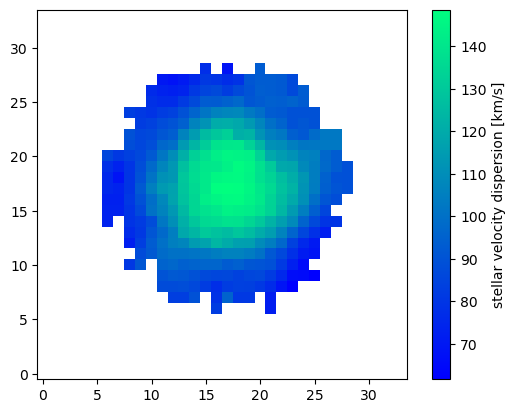

In [11]:
plt.imshow(mstar_sigma, cmap='winter')
plt.gca().invert_yaxis()
plt.colorbar(label='stellar velocity dispersion [km/s]')

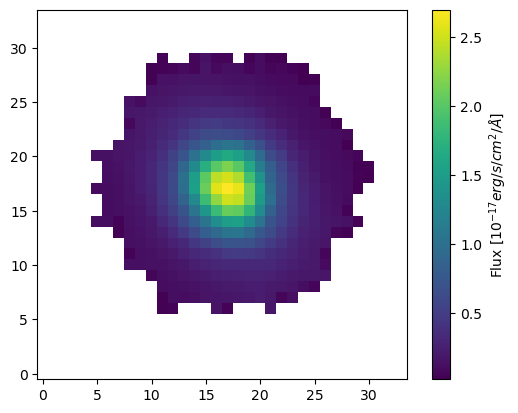

In [12]:
plt.imshow(mflux)
plt.gca().invert_yaxis()
plt.colorbar(label=r'Flux [$10^{-17} erg/s/cm^2/\AA$]')

In [25]:
# deproject velocity map - assume circular

center = np.unravel_index(ma.argmax(mflux), mflux.shape)

array_length = mstar_sigma.shape[0]  # y-coordinate distance
array_width = mstar_sigma.shape[1]  # x-coordinate distance

X_RANGE = np.arange(0, array_width, 1)
Y_RANGE = np.arange(0, array_length, 1)
X_COORD, Y_COORD = np.meshgrid( X_RANGE, Y_RANGE)


x_diff = X_COORD - optical_center[1]
y_diff = Y_COORD - optical_center[0]

radius_px = np.sqrt(x_diff**2 + y_diff**2)
radius_arcsec = radius_px*0.5

dist_to_galaxy_Mpc = c*z/H_0
dist_to_galaxy_kpc = dist_to_galaxy_Mpc*1000
pix_scale_factor = dist_to_galaxy_kpc*np.tan(MANGA_SPAXEL_SIZE)

radius_kpc = radius_px*pix_scale_factor

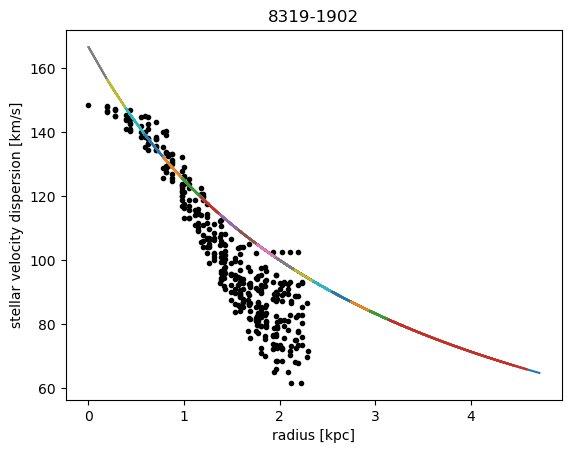

In [47]:
# plot deprojected star vel disp map

plt.scatter(radius_kpc, mstar_sigma, marker='.', color='k')
plt.xlabel('radius [kpc]')
plt.ylabel('stellar velocity dispersion [km/s]')
plt.title(test_gal)
plt.plot(radius_kpc, vel_disp_profile(radius_kpc, 500, 3))

In [46]:
def vel_disp_profile(r, c, a):

    sig = c / (r + a)

    return sig

def chi2_vel(params, r, v, v_ivar):

    model = vel_disp_profile(r, params[0], params[1])
    chi2 = np.sum((model-v)**2*v_ivar)

    return chi2

In [104]:
c0 = 500
c_min = 1
c_max = 100000


a0 = 3
a_min = 0.1
a_max = 50

param_guesses = [c0,a0]
param_bounds = [(c_min, c_max), (a_min, a_max)]

center_mask = radius_px < 4

cmradius_kpc = ma.array(radius_kpc, mask=np.logical_or(vel_maps['star_sigma_mask'], center_mask))
# mask center of map



# cmradius_kpc = ma.array(radius_kpc, mask=center_mask)
cmstar_sigma = ma.array(mstar_sigma, mask=np.logical_or(center_mask, vel_maps['star_sigma_mask']))

res = minimize(chi2_vel,
               param_guesses,
               method = 'Powell',
               args=(cmradius_kpc, cmstar_sigma, mstar_sigma_ivar),
               bounds=param_bounds)

/var/folders/4q/zk1xkb454t7_ncsh3pf51p700000gp/T/ipykernel_69789/4112333866.py:3: RuntimeWarning: divide by zero encountered in divide
  sig = c / (r + a)


In [105]:
np.max(cmradius_kpc)

2.2946406343700634

In [106]:
res

 message: Optimization terminated successfully.
 success: True
  status: 0
     fun: 989.917453969275
       x: [ 2.351e+02  9.498e-01]
     nit: 9
   direc: [[-3.986e+01 -3.846e-01]
           [ 1.007e-01  7.226e-04]]
    nfev: 409

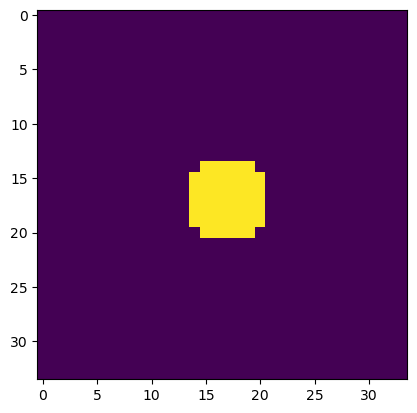

In [107]:
plt.imshow(center_mask)

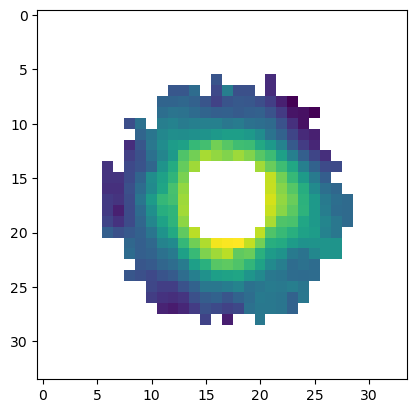

In [108]:
plt.imshow(cmstar_sigma)

$ \sigma(r) = 235 / (r + 0.9) $

plt.scatter(radius_kpc, mstar_sigma, marker='.', color='k')
plt.xlabel('radius [kpc]')
plt.ylabel('stellar velocity dispersion [km/s]')
plt.title(test_gal)
plt.plot(cmradius_kpc.flatten(), (vel_disp_profile(cmradius_kpc, res.x[0], res.x[1])).flatten(), color='r')